# Message ID Overlap: IA vs NWA

Visualizes message-id overlap and reference coverage between the Internet Archive and Norwegian Web Archive.
Data is produced by `scripts/compare_ia_nwa_message_ids.py`.

In [6]:
import json
import matplotlib.pyplot as plt
from matplotlib_venn import venn2


def load(path):
    with open(path) as f:
        return json.load(f)


full = load("../data/ia_nwa_message_id_overlap.json")
filtered = load("../data/ia_nwa_message_id_overlap_date_filtered.json")

## Message ID overlap

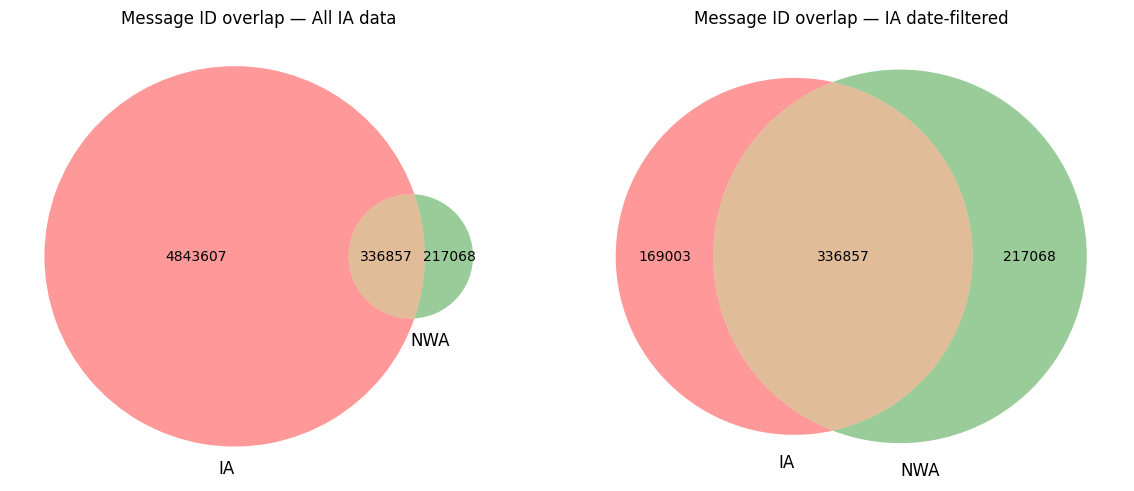

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, data, title in [
    (axes[0], full, "All IA data"),
    (axes[1], filtered, "IA date-filtered"),
]:
    venn2(
        subsets=(data["ids_ia_only"], data["ids_nwa_only"], data["ids_in_both"]),
        set_labels=("IA", "NWA"),
        ax=ax,
    )
    ax.set_title(f"Message ID overlap — {title}")

plt.tight_layout()
plt.show()

## Cross-archive reference resolution

Messages referenced in one archive but missing from it — how many are covered by the other archive?

In [8]:
for label, data in [("Full IA", full), ("IA date-filtered", filtered)]:
    print(f"{label}:")
    print(f"  IA refs resolved by NWA:  {data['ia_refs_resolved_by_nwa']:,}")
    print(f"  NWA refs resolved by IA:  {data['nwa_refs_resolved_by_ia']:,}")
    print()

Full IA:
  IA refs resolved by NWA:  27,246
  NWA refs resolved by IA:  6,488

IA date-filtered:
  IA refs resolved by NWA:  27,203
  NWA refs resolved by IA:  6,488



## Ghost references

Messages cited in References headers but absent from both archives.
Partitioned by which archive(s) cite them.

In [10]:
for label, data in [("Full IA", full), ("IA date-filtered", filtered)]:
    print(f"{label}:")
    print(f"  Cited by IA only:  {data['ghost_cited_by_ia_only']:,}")
    print(f"  Cited by NWA only: {data['ghost_cited_by_nwa_only']:,}")
    print(f"  Cited by both:     {data['ghost_cited_by_both']:,}")
    print()

Full IA:
  Cited by IA only:  174,262
  Cited by NWA only: 5,191
  Cited by both:     5,769

IA date-filtered:
  Cited by IA only:  15,691
  Cited by NWA only: 5,192
  Cited by both:     5,768

